# Module 1 — Executive Revenue Dashboard
**Owner (per project guide):** Member A
**Source data:** `data/processed/master_sales.csv`
**Exports to:** `exports/module1/`

Covers Task 2.1–2.6:
1. Core KPIs (Total Net Revenue, Gross Margin %, AOV, Order Count)
2. Monthly revenue trend & YoY growth rate
3. Revenue distribution by category & channel
4. Branch performance & geographic ranking
5. Margin variance across categories and store formats (channel used as the store-type proxy — see note below)
6. Consolidated executive summary

> **Note on Task 2.5:** the dataset schema does not include a literal `store_type` field.
> `channel` (Online, Branch, Direct Sales, Dealer, Partner) is the closest equivalent — it's the
> actual "how the sale happened" dimension in this data — so it's used in place of store type.
> Flag this substitution in Section 5 / the data dictionary if asked about it.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import os

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

NAVY, BLUE, AMBER, SLATE = '#1E3A5F', '#2563EB', '#F59E0B', '#718096'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
FIG_SIZE = (12, 6.75)

EXPORT_DIR = '../exports/module1'
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_json(obj, name):
    path = f'{EXPORT_DIR}/{name}'
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2, default=str)
    print(f'Saved {path}')

def save_fig(fig, name):
    path = f'{EXPORT_DIR}/{name}'
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved {path}')

df = pd.read_csv('../data/processed/master_sales.csv', low_memory=False)
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
print(df.shape)
df[['transaction_date','category','channel','branch_id','net_revenue','gross_margin']].head()


(50000, 40)


,transaction_date,category,channel,branch_id,net_revenue,gross_margin
0,2024-01-01,Home & Living,Online,BR06,"1,435.32",485.10
1,2024-01-01,Food & Beverage,Branch,BR03,42.39,16.68
2,2024-01-01,Beauty & Personal Care,Dealer,BR05,66.27,11.19
3,2024-01-01,Food & Beverage,Branch,BR02,31.92,6.69
4,2024-01-01,Electronics,Direct Sales,BR03,340.51,-59.09


## Task 2.1 — Core KPIs

**Assertion:** Before any breakdown, the business needs a single, unambiguous set of headline
numbers — total revenue, profitability, typical order size, and volume — that every other
figure in the report and app can be checked against (per the Report Compilation Checklist:
"total revenue in Sec 1 must match Sec 5 & Sec 9").


In [2]:
total_net_revenue = df['net_revenue'].sum()
total_gross_revenue = df['gross_revenue'].sum()
total_gross_margin = df['gross_margin'].sum()
gross_margin_pct = total_gross_margin / total_net_revenue * 100
order_count = df['transaction_id'].nunique()
average_order_value = total_net_revenue / order_count

kpis = {
    'total_net_revenue': round(total_net_revenue, 2),
    'total_gross_revenue': round(total_gross_revenue, 2),
    'total_gross_margin': round(total_gross_margin, 2),
    'gross_margin_pct': round(gross_margin_pct, 2),
    'total_transactions': int(order_count),
    'average_order_value': round(average_order_value, 2),
    'date_range_start': df['transaction_date'].min().strftime('%Y-%m-%d'),
    'date_range_end': df['transaction_date'].max().strftime('%Y-%m-%d'),
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(kpis, 'kpis.json')
kpis


Saved ../exports/module1/kpis.json


/tmp/ipykernel_557/212807762.py:17: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()


{'total_net_revenue': np.float64(18113801.64),
 'total_gross_revenue': np.float64(20250737.96),
 'total_gross_margin': np.float64(5662429.35),
 'gross_margin_pct': np.float64(31.26),
 'total_transactions': 50000,
 'average_order_value': np.float64(362.28),
 'date_range_start': '2024-01-01',
 'date_range_end': '2025-12-31',
 'generated_at': '2026-07-31T06:26:16.153336+00:00'}

### Task 2.1 (Extension) — Total Revenue by Year

Per the brief's exact wording ("Total revenue: Total net revenue **for selected period**"),
the app needs a period-selectable view. The clearest and most report-friendly cut of that is
an annual breakdown, so the reader (or the app's date filter) can see revenue for each calendar
year on its own, not just the 24-month total.


In [3]:
revenue_by_year = df.groupby(df['transaction_date'].dt.year, as_index=False).agg(
    net_revenue=('net_revenue', 'sum'),
    gross_revenue=('gross_revenue', 'sum'),
    gross_margin=('gross_margin', 'sum'),
    transactions=('transaction_id', 'count')
).rename(columns={'transaction_date': 'year'})
revenue_by_year['gross_margin_pct'] = (revenue_by_year['gross_margin'] / revenue_by_year['net_revenue'] * 100).round(2)
revenue_by_year['average_order_value'] = (revenue_by_year['net_revenue'] / revenue_by_year['transactions']).round(2)
revenue_by_year['yoy_growth_pct'] = revenue_by_year['net_revenue'].pct_change().mul(100).round(2)

revenue_by_year_json = {
    'yearly_breakdown': revenue_by_year.round(2).to_dict(orient='records'),
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(revenue_by_year_json, 'revenue_by_year.json')
revenue_by_year


Saved ../exports/module1/revenue_by_year.json


/tmp/ipykernel_557/2249715234.py:13: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()


,year,net_revenue,gross_revenue,gross_margin,transactions,gross_margin_pct,average_order_value,yoy_growth_pct
0,2024,"8,913,164.82","10,030,940.88","2,750,428.47",24819,30.86,359.13,NaN
1,2025,"9,200,636.82","10,219,797.08","2,912,000.88",25181,31.65,365.38,3.23


Saved ../exports/module1/revenue_by_year.png


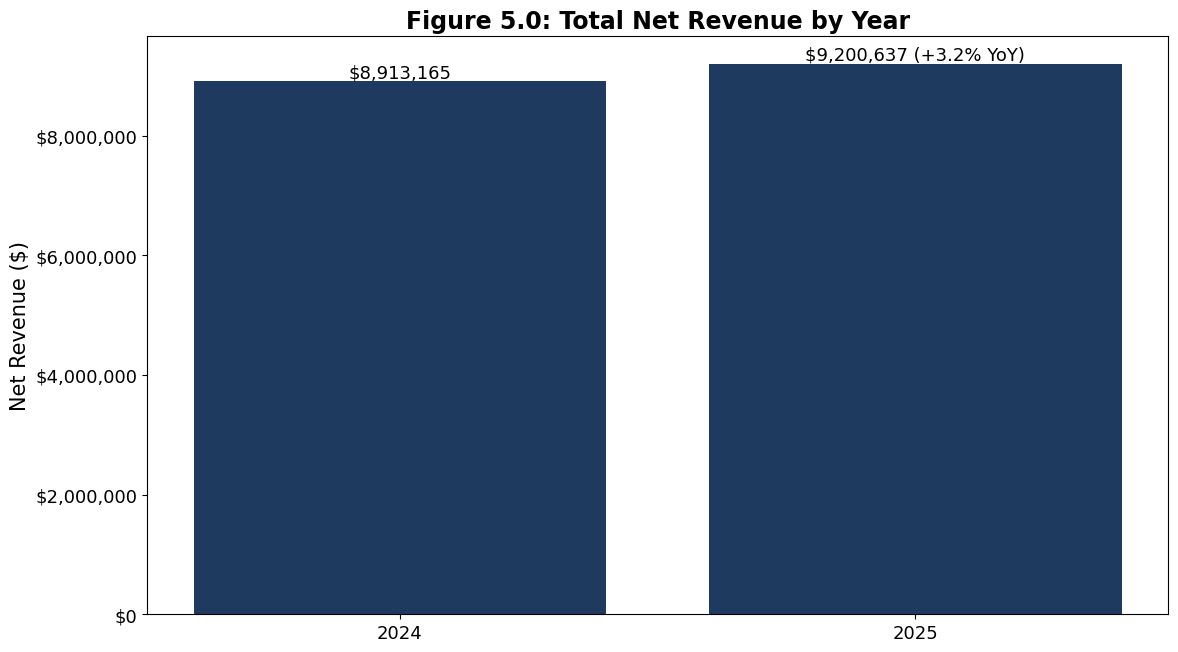

In [4]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.bar(revenue_by_year['year'].astype(str), revenue_by_year['net_revenue'], color=NAVY)
for i, row in revenue_by_year.iterrows():
    label = f"${row['net_revenue']:,.0f}"
    if not pd.isna(row['yoy_growth_pct']):
        label += f" ({row['yoy_growth_pct']:+.1f}% YoY)"
    ax.text(i, row['net_revenue'], label, ha='center', va='bottom', fontsize=13)
ax.set_ylabel('Net Revenue ($)')
ax.set_title('Figure 5.0: Total Net Revenue by Year', fontsize=17, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
save_fig(fig, 'revenue_by_year.png')
plt.show()


## Task 2.2 — Monthly Revenue Trend & YoY Growth

**Method:** Revenue is aggregated to calendar month, then Year-over-Year growth is computed by
comparing each month to the same month one year earlier (not month-over-month, which would
conflate seasonality with real growth).


In [5]:
monthly = df.set_index('transaction_date').resample('MS')['net_revenue'].sum().reset_index()
monthly.columns = ['month', 'net_revenue']
monthly['month_str'] = monthly['month'].dt.strftime('%Y-%m')
monthly['mom_growth_pct'] = monthly['net_revenue'].pct_change().mul(100).round(2)
monthly['yoy_growth_pct'] = monthly['net_revenue'].pct_change(12).mul(100).round(2)

# Latest available YoY figure (most recent month with a same-month-last-year comparison)
latest_yoy = monthly.dropna(subset=['yoy_growth_pct'])
latest_yoy_value = latest_yoy['yoy_growth_pct'].iloc[-1] if len(latest_yoy) else None
latest_yoy_month = latest_yoy['month_str'].iloc[-1] if len(latest_yoy) else None

monthly_trend = {
    'monthly_series': monthly[['month_str','net_revenue','mom_growth_pct','yoy_growth_pct']].round(2).to_dict(orient='records'),
    'latest_yoy_growth_pct': latest_yoy_value,
    'latest_yoy_month': latest_yoy_month,
    'avg_mom_growth_pct': round(monthly['mom_growth_pct'].mean(), 2),
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(monthly_trend, 'monthly_trend.json')
print(f'Latest YoY growth ({latest_yoy_month}): {latest_yoy_value}%')
monthly.tail(6)


Saved ../exports/module1/monthly_trend.json
Latest YoY growth (2025-12): 3.05%


/tmp/ipykernel_557/3040748763.py:17: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()


,month,net_revenue,month_str,mom_growth_pct,yoy_growth_pct
18,2025-07-01,"664,748.28",2025-07,7.38,-2.03
19,2025-08-01,"728,875.22",2025-08,9.65,9.13
20,2025-09-01,"725,877.89",2025-09,-0.41,3.53
21,2025-10-01,"814,560.86",2025-10,12.22,8.10
22,2025-11-01,"995,672.82",2025-11,22.23,4.94
23,2025-12-01,"1,118,619.41",2025-12,12.35,3.05


### Task 2.2 (Detail) — Full Monthly Revenue Table

The brief requires the trend "for every month." The chart above (Figure 5.1) already plots all
months; this cell prints the complete month-by-month table (all months in range, not a preview)
so every value is visible directly in the notebook and can be copied into the report appendix
or a table if needed, alongside `monthly_trend.json` which already contains the full series for
the app.


In [6]:
pd.set_option('display.max_rows', None)
monthly_display = monthly[['month_str','net_revenue','mom_growth_pct','yoy_growth_pct']].rename(
    columns={'month_str':'Month','net_revenue':'Net Revenue','mom_growth_pct':'MoM Growth %','yoy_growth_pct':'YoY Growth %'}
)
print(f'Full monthly series: {len(monthly_display)} months ({monthly_display["Month"].iloc[0]} to {monthly_display["Month"].iloc[-1]})')
monthly_display


Full monthly series: 24 months (2024-01 to 2025-12)


,Month,Net Revenue,MoM Growth %,YoY Growth %
0,2024-01,"744,569.80",NaN,NaN
1,2024-02,"622,378.61",-16.41,NaN
2,2024-03,"715,153.15",14.91,NaN
3,2024-04,"688,371.21",-3.74,NaN
4,2024-05,"682,884.45",-0.80,NaN
5,2024-06,"624,422.76",-8.56,NaN
6,2024-07,"678,545.82",8.67,NaN
7,2024-08,"667,922.62",-1.57,NaN
8,2024-09,"701,128.11",4.97,NaN
9,2024-10,"753,539.31",7.48,NaN


Saved ../exports/module1/monthly_revenue_trend.png


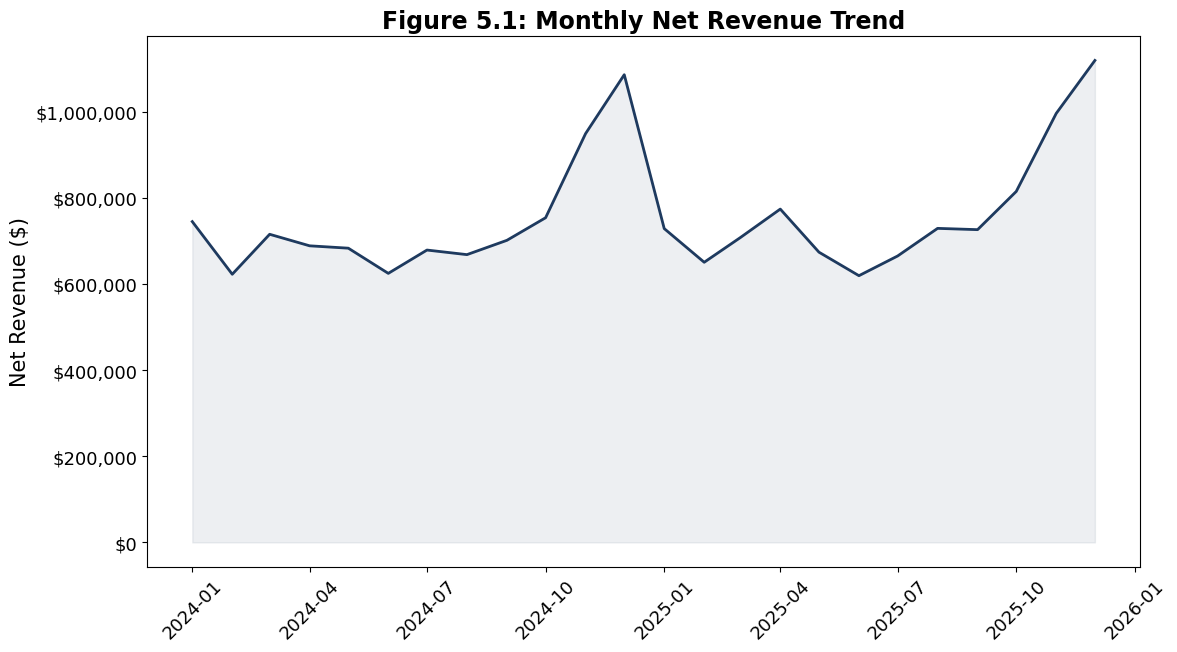

In [7]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(monthly['month'], monthly['net_revenue'], color=NAVY, linewidth=2)
ax.fill_between(monthly['month'], monthly['net_revenue'], color=NAVY, alpha=0.08)
ax.set_ylabel('Net Revenue ($)')
ax.set_title('Figure 5.1: Monthly Net Revenue Trend', fontsize=17, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
save_fig(fig, 'monthly_revenue_trend.png')
plt.show()


## Task 2.3 — Revenue Distribution by Category & Channel

**Assertion:** A quick view of where revenue concentrates by product category and by sales
channel tells the executive reader "what" and "how" the business sells, before drilling into
product- or channel-level detail (which Member B covers in Module 3).


In [8]:
revenue_by_category = df.groupby('category')['net_revenue'].sum().sort_values(ascending=False).round(2)
revenue_by_channel = df.groupby('channel')['net_revenue'].sum().sort_values(ascending=False).round(2)

cat_channel = {
    'by_category': revenue_by_category.to_dict(),
    'by_channel': revenue_by_channel.to_dict(),
    'top_category': revenue_by_category.index[0],
    'top_channel': revenue_by_channel.index[0],
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(cat_channel, 'cat_channel.json')
print(revenue_by_category)
print()
print(revenue_by_channel)


Saved ../exports/module1/cat_channel.json
category
Electronics              5,643,412.89
Home & Living            4,075,719.05
Sports & Outdoors        3,722,247.36
Beauty & Personal Care   2,105,648.60
Apparel                  1,628,850.17
Food & Beverage            937,923.57
Name: net_revenue, dtype: float64

channel
Online         6,392,188.06
Branch         4,492,128.40
Direct Sales   2,720,843.67
Dealer         2,692,183.76
Partner        1,816,457.75
Name: net_revenue, dtype: float64


/tmp/ipykernel_557/1850485196.py:9: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()


Saved ../exports/module1/cat_channel_breakdown.png


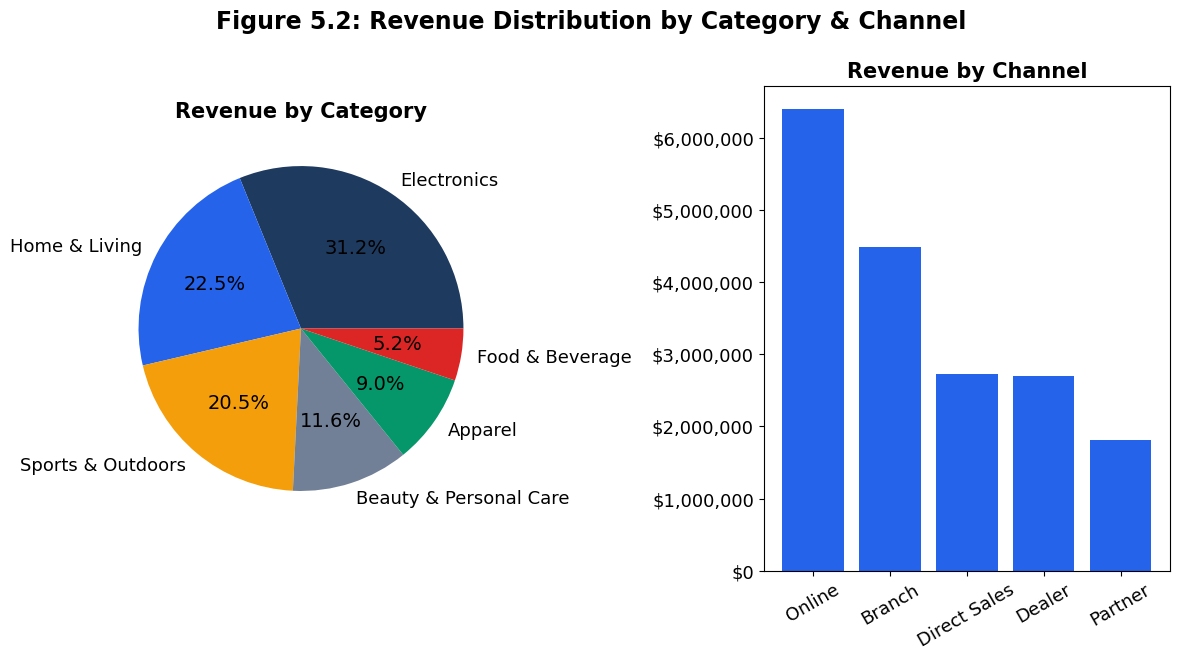

In [9]:
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

axes[0].pie(revenue_by_category.values, labels=revenue_by_category.index, autopct='%1.1f%%',
            colors=[NAVY, BLUE, AMBER, SLATE, '#059669', '#DC2626', '#7C3AED'][:len(revenue_by_category)])
axes[0].set_title('Revenue by Category', fontsize=15, fontweight='bold')

axes[1].bar(revenue_by_channel.index, revenue_by_channel.values, color=BLUE)
axes[1].set_title('Revenue by Channel', fontsize=15, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

fig.suptitle('Figure 5.2: Revenue Distribution by Category & Channel', fontsize=17, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'cat_channel_breakdown.png')
plt.show()


## Task 2.4 — Branch Performance & Geographical Ranking

**Note:** this duplicates part of Member B's Module 3 branch analysis (Task 4.5) by design —
the project guide assigns a *dashboard-level* branch view to Module 1 and a *deeper tiered
analysis* to Module 3. Keep this one high-level (ranking only); the tiering/segmentation detail
belongs in Section 7, not Section 5.


In [10]:
branch_perf = df.groupby('branch_id', as_index=False).agg(
    net_revenue=('net_revenue', 'sum'),
    transactions=('transaction_id', 'count')
).sort_values('net_revenue', ascending=False).reset_index(drop=True)
branch_perf['rank'] = branch_perf.index + 1
branch_perf['revenue_share_pct'] = (branch_perf['net_revenue'] / branch_perf['net_revenue'].sum() * 100).round(2)

branch_perf_json = {
    'ranking': branch_perf.round(2).to_dict(orient='records'),
    'top_branch': branch_perf.iloc[0]['branch_id'],
    'bottom_branch': branch_perf.iloc[-1]['branch_id'],
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(branch_perf_json, 'branch_perf.json')
branch_perf


Saved ../exports/module1/branch_perf.json


/tmp/ipykernel_557/2560912951.py:12: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()


,branch_id,net_revenue,transactions,rank,revenue_share_pct
0,BR01,"3,250,357.65",8950,1,17.94
1,BR02,"2,664,098.66",7522,2,14.71
2,BR03,"2,540,622.25",7053,3,14.03
3,BR04,"2,417,565.75",6374,4,13.35
4,BR05,"2,165,589.80",6047,5,11.96
5,BR06,"1,847,936.41",5139,6,10.20
6,BR07,"1,826,339.55",4929,7,10.08
7,BR08,"1,401,291.57",3986,8,7.74


Saved ../exports/module1/branch_ranking.png


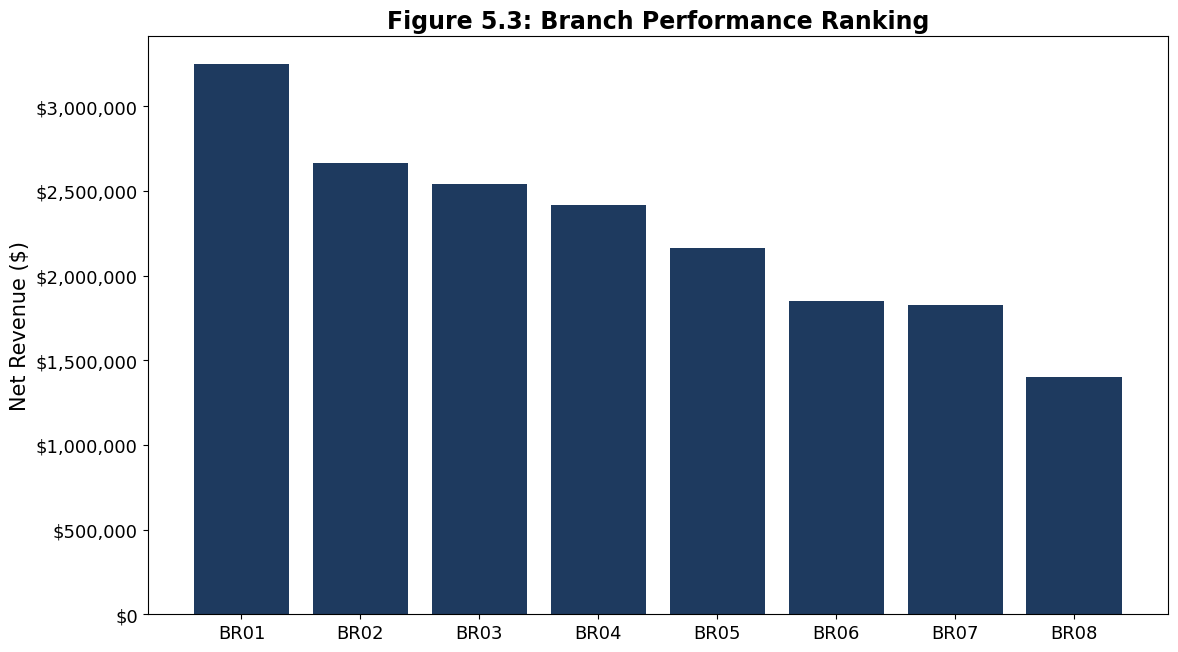

In [11]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.bar(branch_perf['branch_id'], branch_perf['net_revenue'], color=NAVY)
ax.set_ylabel('Net Revenue ($)')
ax.set_title('Figure 5.3: Branch Performance Ranking', fontsize=17, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
save_fig(fig, 'branch_ranking.png')
plt.show()


## Task 2.5 — Margin Variance Across Categories and Store Formats (Channel)

**Method:** Gross margin % (not just $ margin) is computed per category and per channel, then
variance/standard deviation across each grouping is reported — this shows not just *which*
segment is most profitable, but *how consistent* profitability is within the business.


In [12]:
margin_by_category = df.groupby('category', as_index=False).agg(
    net_revenue=('net_revenue', 'sum'),
    gross_margin=('gross_margin', 'sum'),
    margin_pct_mean=('margin_percentage_tx', 'mean'),
    margin_pct_std=('margin_percentage_tx', 'std')
).round(2)

margin_by_channel = df.groupby('channel', as_index=False).agg(
    net_revenue=('net_revenue', 'sum'),
    gross_margin=('gross_margin', 'sum'),
    margin_pct_mean=('margin_percentage_tx', 'mean'),
    margin_pct_std=('margin_percentage_tx', 'std')
).round(2)

margin_analysis = {
    'by_category': margin_by_category.to_dict(orient='records'),
    'by_channel_as_store_type_proxy': margin_by_channel.to_dict(orient='records'),
    'highest_margin_category': margin_by_category.loc[margin_by_category['margin_pct_mean'].idxmax(), 'category'],
    'lowest_margin_category': margin_by_category.loc[margin_by_category['margin_pct_mean'].idxmin(), 'category'],
    'most_variable_category': margin_by_category.loc[margin_by_category['margin_pct_std'].idxmax(), 'category'],
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(margin_analysis, 'margin_analysis.json')
print(margin_by_category)
print()
print(margin_by_channel)


Saved ../exports/module1/margin_analysis.json
                 category  net_revenue  gross_margin  margin_pct_mean  \
0                 Apparel 1,628,850.17    446,362.41            25.66   
1  Beauty & Personal Care 2,105,648.60    727,339.68            34.81   
2             Electronics 5,643,412.89  2,132,664.94            34.51   
3         Food & Beverage   937,923.57    268,050.50            28.62   
4           Home & Living 4,075,719.05  1,095,488.22            26.59   
5       Sports & Outdoors 3,722,247.36    992,523.60            24.28   

   margin_pct_std  
0           12.33  
1           13.21  
2           15.83  
3           13.23  
4           10.33  
5           19.05  

        channel  net_revenue  gross_margin  margin_pct_mean  margin_pct_std
0        Branch 4,492,128.40  1,391,187.67            28.62           14.65
1        Dealer 2,692,183.76    840,527.93            28.43           14.72
2  Direct Sales 2,720,843.67    859,494.38            28.82           14.

/tmp/ipykernel_557/2875663288.py:21: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()


Saved ../exports/module1/margin_variance_category.png


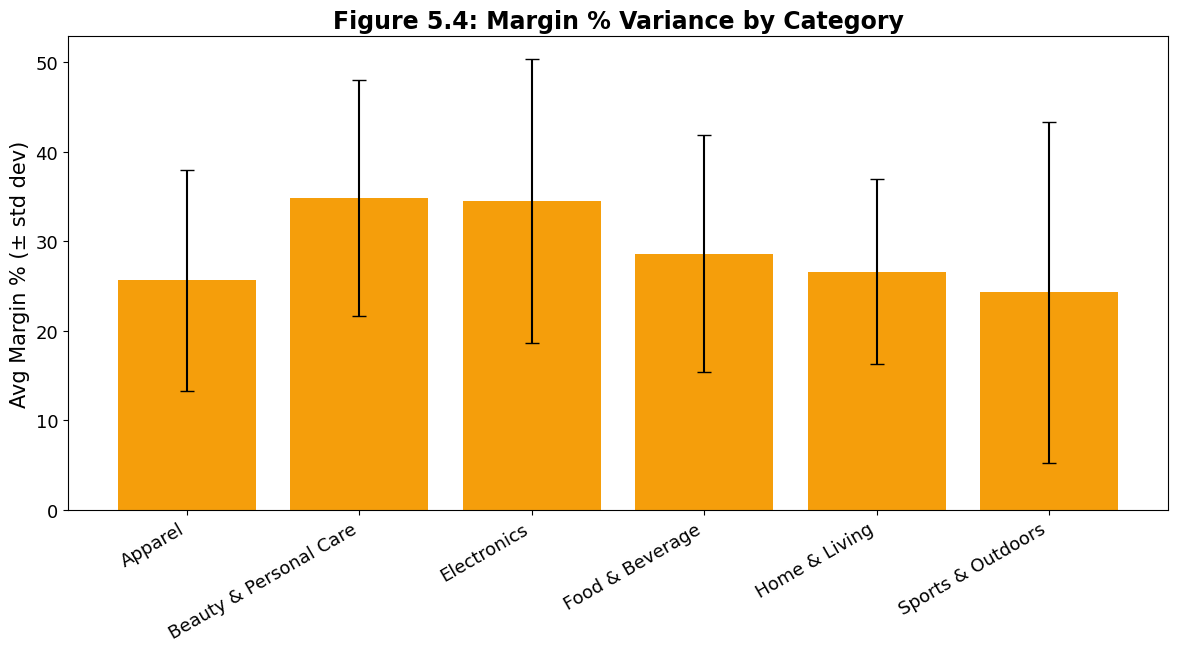

In [13]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
x = np.arange(len(margin_by_category))
ax.bar(x, margin_by_category['margin_pct_mean'], yerr=margin_by_category['margin_pct_std'],
       color=AMBER, capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(margin_by_category['category'], rotation=30, ha='right')
ax.set_ylabel('Avg Margin % (± std dev)')
ax.set_title('Figure 5.4: Margin % Variance by Category', fontsize=17, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'margin_variance_category.png')
plt.show()


## Task 2.6 — Consolidated Executive Summary

Pulls every KPI above into one export for the app's header summary bar (Page 1, per Member D's
Web App Architecture spec) and gives a single console printout for the report narrative.


In [14]:
executive_summary = {
    'headline_kpis': kpis,
    'revenue_trend_snapshot': {
        'latest_yoy_growth_pct': latest_yoy_value,
        'avg_mom_growth_pct': monthly_trend['avg_mom_growth_pct']
    },
    'top_category': cat_channel['top_category'],
    'top_channel': cat_channel['top_channel'],
    'top_branch': branch_perf_json['top_branch'],
    'bottom_branch': branch_perf_json['bottom_branch'],
    'highest_margin_category': margin_analysis['highest_margin_category'],
    'lowest_margin_category': margin_analysis['lowest_margin_category'],
    'generated_at': pd.Timestamp.utcnow().isoformat()
}
save_json(executive_summary, 'executive_summary.json')

print('=== MODULE 1 KEY NUMBERS FOR SECTION 5 ===')
print(f"Total Net Revenue: ${kpis['total_net_revenue']:,.0f} | Gross Margin: {kpis['gross_margin_pct']}%")
print(f"Total Transactions: {kpis['total_transactions']:,} | AOV: ${kpis['average_order_value']:,.2f}")
print(f"Latest YoY growth ({latest_yoy_month}): {latest_yoy_value}%")
print(f"Top category: {cat_channel['top_category']} | Top channel: {cat_channel['top_channel']}")
print(f"Top branch: {branch_perf_json['top_branch']} | Weakest branch: {branch_perf_json['bottom_branch']}")
print(f"Highest-margin category: {margin_analysis['highest_margin_category']} | "
      f"Lowest-margin category: {margin_analysis['lowest_margin_category']}")


Saved ../exports/module1/executive_summary.json
=== MODULE 1 KEY NUMBERS FOR SECTION 5 ===
Total Net Revenue: $18,113,802 | Gross Margin: 31.26%
Total Transactions: 50,000 | AOV: $362.28
Latest YoY growth (2025-12): 3.05%
Top category: Electronics | Top channel: Online
Top branch: BR01 | Weakest branch: BR08
Highest-margin category: Beauty & Personal Care | Lowest-margin category: Sports & Outdoors


/tmp/ipykernel_557/2100803563.py:13: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  'generated_at': pd.Timestamp.utcnow().isoformat()
